In [1]:
# Import library tambahan jika diperlukan
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [2]:
# 1. Load Dataset
url_marketing = "marketing_data.csv"
df_marketing = pd.read_csv(url_marketing)

In [3]:
print("--- 5 Data Pertama Marketing ---")
print(df_marketing.head())

--- 5 Data Pertama Marketing ---
   youtube  facebook  newspaper  sales
0    84.72     19.20      48.96  12.60
1   351.48     33.96      51.84  25.68
2   135.48     20.88      46.32  14.28
3   116.64      1.80      36.00  11.52
4   318.72     24.00       0.36  20.88


In [4]:
# 2. Pemisahan Fitur Multiple (X) dan Target (y)
X_multi = df_marketing[["youtube", "facebook", "newspaper"]]
y_multi = df_marketing["sales"]

In [5]:
# 3. Split Data (80% Train, 20% Test)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

In [6]:
# 4. Melatih Model Multiple Linear Regression
model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 0.04, 0.19,-0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['youtube','facebook','newspaper']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.703
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [7]:
# 5. Prediksi
y_pred_m = model_multi.predict(X_test_m)

In [8]:
# 6. Evaluasi Model
mse_m = mean_squared_error(y_test_m, y_pred_m)
rmse_m = np.sqrt(mse_m)
r2_m = r2_score(y_test_m, y_pred_m)

In [9]:
print("\n--- Evaluasi Multiple Linear Regression ---")
print("Koefisien:")
for col, coef in zip(X_multi.columns, model_multi.coef_):
  print(f"  - {col}: {coef:.4f}")
print(f"Intercept: {model_multi.intercept_:.4f}")
print(f"MSE: {mse_m:.4f}")
print(f"RMSE: {rmse_m:.4f}")
print(f"R-squared (R2): {r2_m:.4f}")


--- Evaluasi Multiple Linear Regression ---
Koefisien:
  - youtube: 0.0442
  - facebook: 0.1945
  - newspaper: -0.0000
Intercept: 3.7030
MSE: 5.5768
RMSE: 2.3615
R-squared (R2): 0.8729


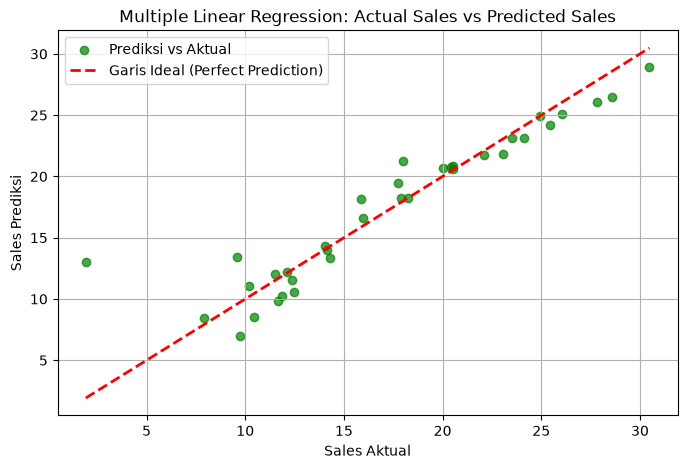

In [10]:
# 7. Visualisasi Aktual vs Hasil Prediksi
plt.figure(figsize=(8, 5))
plt.scatter(
    y_test_m, y_pred_m, color="green", alpha=0.7, label="Prediksi vs Aktual"
)
plt.plot(
    [y_test_m.min(), y_test_m.max()],
    [y_test_m.min(), y_test_m.max()],
    "r--",
    lw=2,
    label="Garis Ideal (Perfect Prediction)",
)
plt.title("Multiple Linear Regression: Actual Sales vs Predicted Sales")
plt.xlabel("Sales Aktual")
plt.ylabel("Sales Prediksi")
plt.legend()
plt.grid(True)
plt.show()